# Análise exploratória dos dados telefônicos de Campinas

Este notebook faz uma análise exploratória simples da base `Campinas.parquet`.

O foco aqui é entender a estrutura dos dados, o comportamento dos emissores, o volume de chamadas, a diversidade de contatos, a distância residencial já presente no parquet e preparar uma tabela de arestas emissor-receptor. Nenhuma etapa usa o arquivo `residencias.csv`.

## Perguntas desta EDA

- Quantos emissores existem na base?
- As colunas do parquet estão consistentes?
- Como se distribuem o total de chamadas e a quantidade de receptores por emissor?
- Poucos emissores concentram muitas chamadas?
- Como transformar as listas internas em uma tabela simples de arestas emissor-receptor?
- As chamadas estão concentradas em poucos pares emissor-receptor?
- Como se distribuem as distâncias residenciais entre emissores e receptores?
- Existe alguma relação aparente entre distância residencial, quantidade de chamadas e duração?
- Os emissores tendem a falar com muitos contatos ou concentrar chamadas em poucos contatos?

## Imports e caminhos

In [1]:
from pathlib import Path
import sys
from config import CITY_NAME, CITY_PARQUET

# Evita extensões opcionais que podem causar conflito em alguns ambientes.
sys.modules['numexpr'] = None
sys.modules['bottleneck'] = None

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('../dados')
CITY_PATH = DATA_DIR / CITY_PARQUET
RESIDENCIAS_PATH = DATA_DIR / 'residencias.csv'

CITY_PATH.exists()

True

In [2]:
CITY_PATH

WindowsPath('../dados/cabofrio.parquet')

## Dicionário dos dados usados

| Coluna | Como será usada aqui |
|---|---|
| `id_emisor` | Identificador anonimizado do usuário emissor. |
| `total_calls_make` | Total de chamadas feitas pelo emissor. |
| `unique_receivers` | Quantidade de receptores distintos chamados pelo emissor. |
| `IDs_receivers_corr` | Lista de receptores associados ao emissor. |
| `q_calls_corr` | Lista com a quantidade de chamadas para cada receptor. |
| `residence_distance_km_corr` | Lista com a distância residencial, em km, entre emissor e receptor. |
| `calls_duration_total_corr` | Lista com a duração total das chamadas para cada receptor. |

## Carregamento da base

Antes de carregar tudo, olhamos rapidamente o schema do parquet. Depois lemos a base em memória, porque o arquivo de Campinas é pequeno para uma EDA local.

In [3]:
parquet_file = pq.ParquetFile(CITY_PATH)
print(parquet_file.schema)
print(f'Linhas: {parquet_file.metadata.num_rows:,}')
print(f'Grupos de linhas: {parquet_file.metadata.num_row_groups}')

required group field_id=-1 schema {
  optional binary field_id=-1 city_residences (String);
  optional binary field_id=-1 id_emisor (String);
  optional int64 field_id=-1 total_calls_make;
  optional int64 field_id=-1 unique_receivers;
  optional group field_id=-1 IDs_receivers_corr (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 q_calls_corr (List) {
    repeated group field_id=-1 list {
      optional int64 field_id=-1 element;
    }
  }
  optional group field_id=-1 residence_distance_km_corr (List) {
    repeated group field_id=-1 list {
      optional double field_id=-1 element;
    }
  }
  optional group field_id=-1 calls_duration_total_corr (List) {
    repeated group field_id=-1 list {
      optional double field_id=-1 element;
    }
  }
}

Linhas: 620
Grupos de linhas: 1


In [4]:
df = parquet_file.read().to_pandas()
df

,city_residences,id_emisor,total_calls_make,unique_receivers,IDs_receivers_corr,q_calls_corr,residence_distance_km_corr,calls_duration_total_corr
0,Cabo Frio,B0721B8F6D9BC77060EB8C8CE42932E4,1,1,[471E4FEA209C44193618D6A49E4D5E22],[1],[6.13366162313048],[0.22]
1,Cabo Frio,335B75C51B91846F8B277C61E279BC39,1,1,[515498B51D4D0328105D210A1F6E61B2],[1],[0.0],[1.53]
2,Cabo Frio,6261F451918FB10EE4A26EE87A3E3110,2,2,"[6261F451918FB10EE4A26EE87A3E3110, 725FCCCFBC7C12FCBE91A9F51A6D15B3]","[1, 1]","[0.0, 0.0]","[0.07, 0.23]"
3,Cabo Frio,CA466A0CD69396A5ED655F20F4B43751,78,3,"[79BF0D2CA01FFB148505FE0DBFAE84B3, 4CFDCA8864007F2DEAF12DAC1C92075F, 94D64E4...","[21, 18, 39]","[0.0, 1.8607921310263857, 1.4864557700574927]","[37.67, 18.12, 36.17]"
4,Cabo Frio,D34CEEE11E6EA3158D474CC2B036B8C0,66,3,"[EF59027DD925CD61923C97A2B95C7F0E, 2FB3656A9C886BC34808871C04D69B66, 9BB2635...","[6, 45, 15]","[0.0, 1.4864557700574927, 0.0]","[3.0700000000000003, 19.0, 4.999999999999999]"
...,...,...,...,...,...,...,...,...
615,Cabo Frio,9A23535D6E365682ACE52D85E49601FE,1,1,[C5F77B113A4B25691C72D16BDC2328D7],[1],[2.2713206902996497],[0.08]
616,Cabo Frio,741F1D559375CDD0714BED13C7E2FF72,4,1,[AD256C578DC85F116E47E183E790B2DF],[4],[0.0],[3.24]
617,Cabo Frio,815CFC1D537C53702368BF0EF155384E,11,1,[C3ED7531F5A500CB37220A5C26B63FF4],[11],[7.868250158719237],[32.769999999999996]
618,Cabo Frio,09E962CA548565F345A0B0121EE04F50,30,2,"[D0E7F131693DB0F87E13066511473D65, D2B61B4DC6676DCA914139A70CF0B526]","[29, 1]","[0.0, 0.0]","[90.57, 1.52]"


## Qualidade e consistência

Esta etapa verifica se há nulos, quantos valores únicos existem por coluna e se as listas internas batem com os totais declarados. Isso é importante porque cada posição das listas representa o mesmo par emissor-receptor.

In [5]:
resumo_colunas = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': df.isna().mean(),
    'n_unicos': [df[col].astype(str).nunique() for col in df.columns],
})
resumo_colunas

,tipo,nulos,pct_nulos,n_unicos
city_residences,str,0,0.0,1
id_emisor,str,0,0.0,620
total_calls_make,int64,0,0.0,110
unique_receivers,int64,0,0.0,9
IDs_receivers_corr,object,0,0.0,568
q_calls_corr,object,0,0.0,266
residence_distance_km_corr,object,0,0.0,179
calls_duration_total_corr,object,0,0.0,565


In [6]:
list_cols = ['IDs_receivers_corr', 'q_calls_corr', 'residence_distance_km_corr', 'calls_duration_total_corr']

for col in list_cols:
    df[f'n_{col}'] = df[col].apply(len)

df['soma_q_calls_corr'] = df['q_calls_corr'].apply(sum)

checks = pd.DataFrame({
    'linhas': [len(df)],
    'emissores_unicos': [df['id_emisor'].nunique()],
    'emissores_duplicados': [df['id_emisor'].duplicated().sum()],
    'unique_receivers_confere': [(df['unique_receivers'] == df['n_IDs_receivers_corr']).all()],
    'listas_mesmo_tamanho': [(df[[f'n_{c}' for c in list_cols]].nunique(axis=1) == 1).all()],
    'total_calls_confere': [(df['total_calls_make'] == df['soma_q_calls_corr']).all()],
})
checks

,linhas,emissores_unicos,emissores_duplicados,unique_receivers_confere,listas_mesmo_tamanho,total_calls_confere
0,620,620,0,True,True,True


In [7]:
inconsistencias = df.loc[
    (df['unique_receivers'] != df['n_IDs_receivers_corr']) |
    (df[[f'n_{c}' for c in list_cols]].nunique(axis=1) != 1) |
    (df['total_calls_make'] != df['soma_q_calls_corr']),
    ['id_emisor', 'total_calls_make', 'soma_q_calls_corr', 'unique_receivers'] + [f'n_{c}' for c in list_cols]
]

inconsistencias.head()

,id_emisor,total_calls_make,soma_q_calls_corr,unique_receivers,n_IDs_receivers_corr,n_q_calls_corr,n_residence_distance_km_corr,n_calls_duration_total_corr


## Visão geral dos emissores

Cada linha representa um emissor. Aqui criamos uma métrica simples, `chamadas_por_receptor`, que ajuda a diferenciar quem liga para muitos contatos de quem concentra chamadas em poucos contatos.

In [8]:
df['chamadas_por_receptor'] = df['total_calls_make'] / df['unique_receivers'].replace(0, np.nan)

resumo_geral = pd.DataFrame({
    'emissores': [df['id_emisor'].nunique()],
    'chamadas_total': [df['total_calls_make'].sum()],
    'receptores_distintos_somados': [df['unique_receivers'].sum()],
    'media_chamadas_por_emissor': [df['total_calls_make'].mean()],
    'mediana_chamadas_por_emissor': [df['total_calls_make'].median()],
    'media_receptores_por_emissor': [df['unique_receivers'].mean()],
    'mediana_receptores_por_emissor': [df['unique_receivers'].median()],
})
resumo_geral

,emissores,chamadas_total,receptores_distintos_somados,media_chamadas_por_emissor,mediana_chamadas_por_emissor,media_receptores_por_emissor,mediana_receptores_por_emissor
0,620,15812,996,25.503226,13.0,1.606452,1.0


In [9]:
emissor_cols = ['total_calls_make', 'unique_receivers', 'chamadas_por_receptor']
df[emissor_cols].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
total_calls_make,620.0,25.503226,38.142683,1.0,1.0,1.0,3.0,13.0,32.0,66.0,102.050,147.43,497.0
unique_receivers,620.0,1.606452,1.155149,1.0,1.0,1.0,1.0,1.0,2.0,3.0,3.000,7.00,9.0
chamadas_por_receptor,620.0,17.059455,26.014430,1.0,1.0,1.0,2.0,8.0,21.0,39.7,66.075,126.62,248.5


## Distribuições dos emissores

O primeiro gráfico mostra a distribuição original do total de chamadas. O segundo usa `log1p`, isto é, `log(1 + x)`, para enxergar melhor a cauda da distribuição quando há poucos usuários muito ativos.

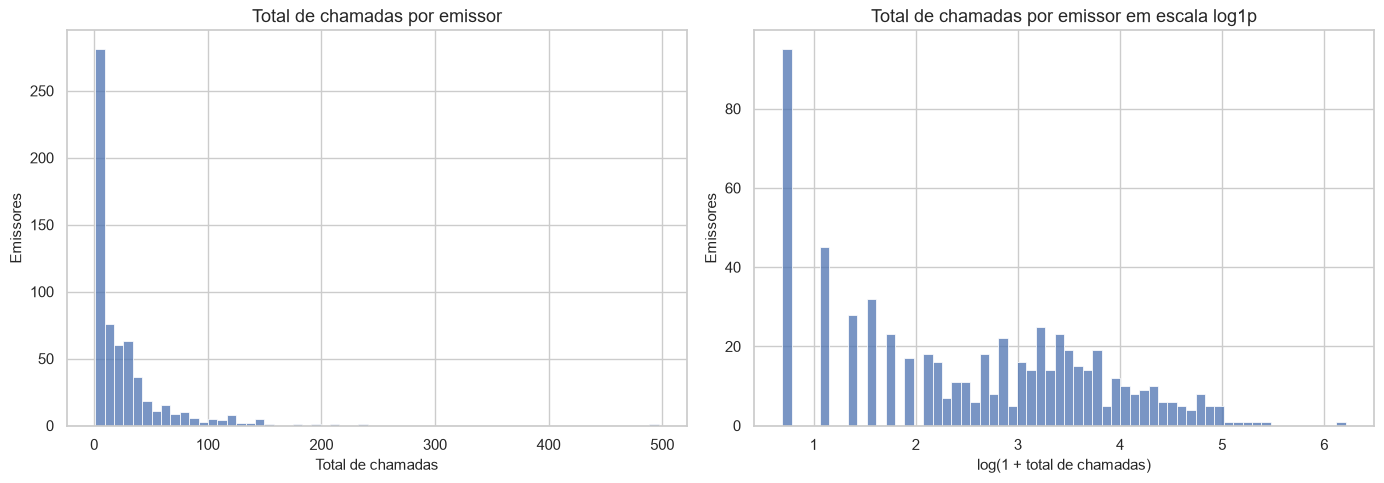

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='total_calls_make', bins=60, ax=axes[0])
axes[0].set_title('Total de chamadas por emissor')
axes[0].set_xlabel('Total de chamadas')
axes[0].set_ylabel('Emissores')

sns.histplot(x=np.log1p(df['total_calls_make']), bins=60, ax=axes[1])
axes[1].set_title('Total de chamadas por emissor em escala log1p')
axes[1].set_xlabel('log(1 + total de chamadas)')
axes[1].set_ylabel('Emissores')

plt.tight_layout()
plt.show()

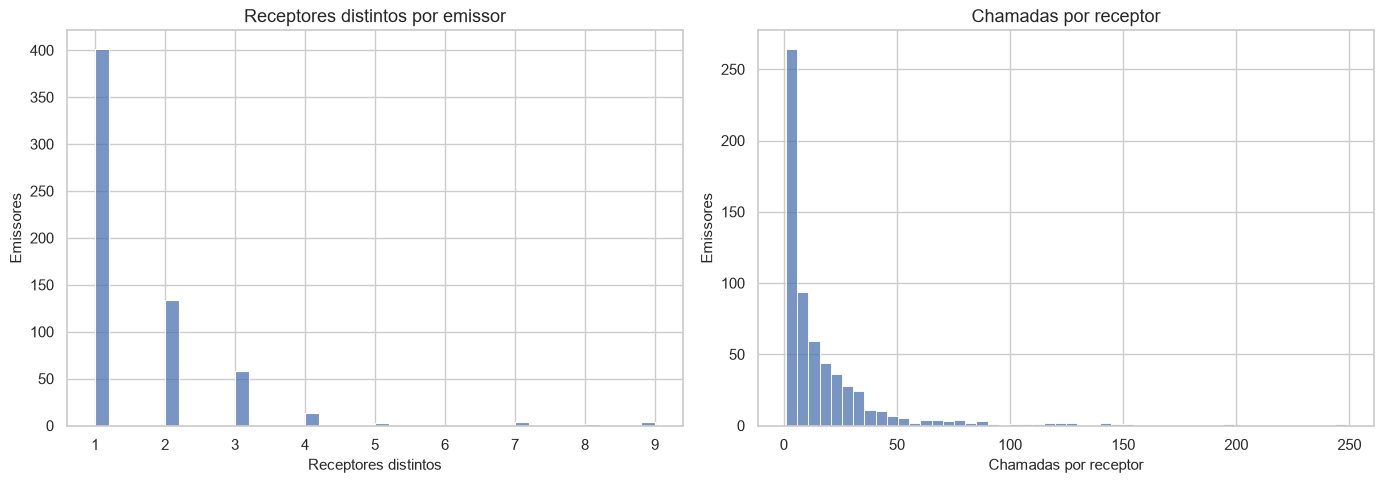

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='unique_receivers', bins=40, ax=axes[0])
axes[0].set_title('Receptores distintos por emissor')
axes[0].set_xlabel('Receptores distintos')
axes[0].set_ylabel('Emissores')

sns.histplot(data=df, x='chamadas_por_receptor', bins=50, ax=axes[1])
axes[1].set_title('Chamadas por receptor')
axes[1].set_xlabel('Chamadas por receptor')
axes[1].set_ylabel('Emissores')

plt.tight_layout()
plt.show()

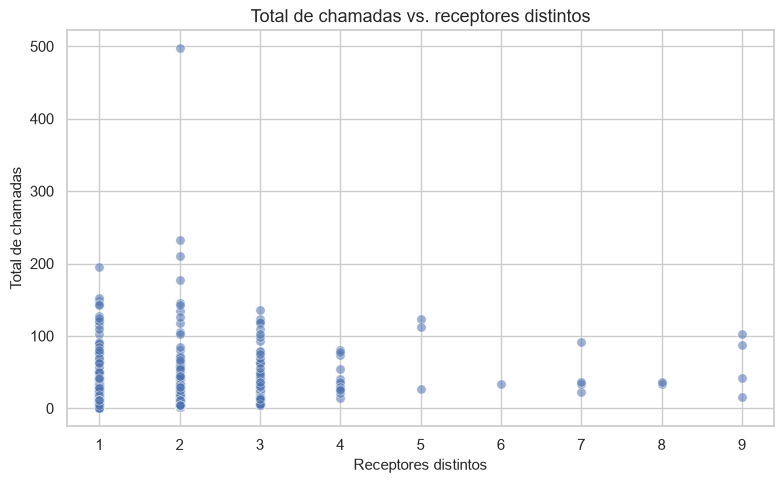

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='unique_receivers',
    y='total_calls_make',
    alpha=0.55,
    s=45,
)
plt.title('Total de chamadas vs. receptores distintos')
plt.xlabel('Receptores distintos')
plt.ylabel('Total de chamadas')
plt.tight_layout()
plt.show()

## Emissores mais ativos

A tabela abaixo mostra os emissores com maior volume de chamadas. Ela ajuda a identificar se existem observações muito acima do restante da base.

In [13]:
top_emissores = df[[
    'id_emisor',
    'total_calls_make',
    'unique_receivers',
    'chamadas_por_receptor',
]].sort_values('total_calls_make', ascending=False)

top_emissores.head(15)

,id_emisor,total_calls_make,unique_receivers,chamadas_por_receptor
395,A694EAAE540B4685FF4B3CA22E752CC4,497,2,248.500000
182,083A9B1C5FC4E664A3BF77504FB0D29A,233,2,116.500000
427,841A266A864A648E813FC3CB28B3C9EB,211,2,105.500000
105,C83DCF1F09C87A0F41E73B86D358FECB,195,1,195.000000
544,FE85CD2DDFDB0128B1DCC2DF844EBCE0,177,2,88.500000
249,8D12000117F1AA6F8BAAEE9069692A2B,152,1,152.000000
164,BFB32904DF9F1ACE6D08E2B214308F2F,148,1,148.000000
342,F3A28E08A5C9A37159AA4994AFEB2E1E,145,2,72.500000
350,88B8A886BF951C5C35ED42E2D3EF072D,144,1,144.000000
482,81C009C82ECF9B1A268FC3C4072AC8CC,143,2,71.500000


## Pareto do volume de chamadas

O Pareto mede concentração. Aqui a pergunta é: qual percentual das chamadas vem dos emissores mais ativos? Se poucos emissores explicam grande parte das chamadas, a curva sobe rapidamente.

In [14]:
pareto = df[['id_emisor', 'total_calls_make', 'unique_receivers']].sort_values('total_calls_make', ascending=False).reset_index(drop=True)
pareto['rank'] = np.arange(1, len(pareto) + 1)
pareto['pct_emissores'] = pareto['rank'] / len(pareto)
pareto['pct_chamadas_acum'] = pareto['total_calls_make'].cumsum() / pareto['total_calls_make'].sum()
pareto.head(10)

,id_emisor,total_calls_make,unique_receivers,rank,pct_emissores,pct_chamadas_acum
0,A694EAAE540B4685FF4B3CA22E752CC4,497,2,1,0.001613,0.031432
1,083A9B1C5FC4E664A3BF77504FB0D29A,233,2,2,0.003226,0.046167
2,841A266A864A648E813FC3CB28B3C9EB,211,2,3,0.004839,0.059512
3,C83DCF1F09C87A0F41E73B86D358FECB,195,1,4,0.006452,0.071844
4,FE85CD2DDFDB0128B1DCC2DF844EBCE0,177,2,5,0.008065,0.083038
5,8D12000117F1AA6F8BAAEE9069692A2B,152,1,6,0.009677,0.092651
6,BFB32904DF9F1ACE6D08E2B214308F2F,148,1,7,0.011290,0.102011
7,F3A28E08A5C9A37159AA4994AFEB2E1E,145,2,8,0.012903,0.111181
8,88B8A886BF951C5C35ED42E2D3EF072D,144,1,9,0.014516,0.120288
9,81C009C82ECF9B1A268FC3C4072AC8CC,143,2,10,0.016129,0.129332


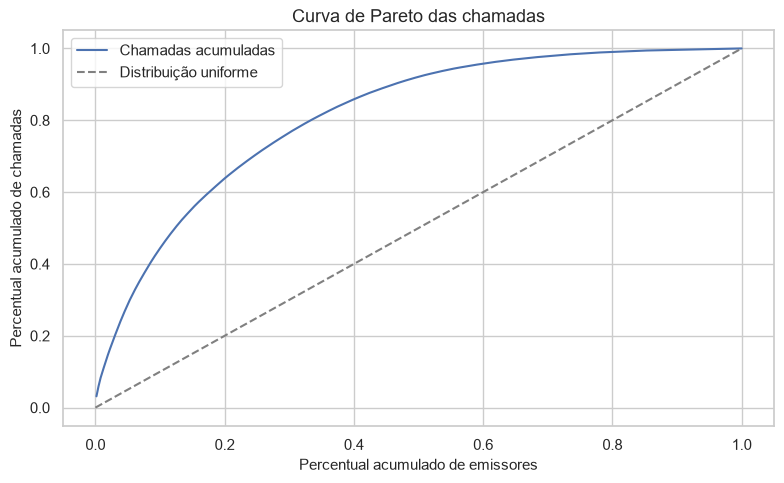

Top 1% dos emissores: 10.2% das chamadas
Top 5% dos emissores: 28.7% das chamadas
Top 10% dos emissores: 44.4% das chamadas
Top 20% dos emissores: 63.8% das chamadas


In [15]:
plt.figure(figsize=(8, 5))
plt.plot(pareto['pct_emissores'], pareto['pct_chamadas_acum'], label='Chamadas acumuladas')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Distribuição uniforme')
plt.title('Curva de Pareto das chamadas')
plt.xlabel('Percentual acumulado de emissores')
plt.ylabel('Percentual acumulado de chamadas')
plt.legend()
plt.tight_layout()
plt.show()

for corte in [0.01, 0.05, 0.10, 0.20]:
    n = max(1, int(np.ceil(corte * len(pareto))))
    pct = pareto.loc[:n-1, 'total_calls_make'].sum() / pareto['total_calls_make'].sum()
    print(f'Top {corte:.0%} dos emissores: {pct:.1%} das chamadas')

## Preparação da tabela de arestas emissor-receptor

O parquet guarda os receptores em listas. Para analisar pares emissor-receptor, expandimos essas listas para uma tabela em que cada linha é um par.

A tabela de arestas inclui quantidade de chamadas, duração total, duração média por chamada e distância residencial em km.

In [16]:
edges_records = []

for row in df.itertuples(index=False):
    for receiver, q_calls, distance_km, duration_total in zip(
        row.IDs_receivers_corr,
        row.q_calls_corr,
        row.residence_distance_km_corr,
        row.calls_duration_total_corr,
    ):
        edges_records.append({
            'id_emisor': row.id_emisor,
            'id_receiver': receiver,
            'q_calls': q_calls,
            'residence_distance_km': distance_km,
            'calls_duration_total': duration_total,
        })

edges = pd.DataFrame(edges_records)
edges['avg_duration_per_call'] = edges['calls_duration_total'] / edges['q_calls'].replace(0, np.nan)
edges.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call
0,B0721B8F6D9BC77060EB8C8CE42932E4,471E4FEA209C44193618D6A49E4D5E22,1,6.133662,0.22,0.22000
1,335B75C51B91846F8B277C61E279BC39,515498B51D4D0328105D210A1F6E61B2,1,0.000000,1.53,1.53000
2,6261F451918FB10EE4A26EE87A3E3110,6261F451918FB10EE4A26EE87A3E3110,1,0.000000,0.07,0.07000
3,6261F451918FB10EE4A26EE87A3E3110,725FCCCFBC7C12FCBE91A9F51A6D15B3,1,0.000000,0.23,0.23000
4,CA466A0CD69396A5ED655F20F4B43751,79BF0D2CA01FFB148505FE0DBFAE84B3,21,0.000000,37.67,1.79381


In [17]:
resumo_edges = pd.DataFrame({
    'arestas': [len(edges)],
    'emissores': [edges['id_emisor'].nunique()],
    'receptores': [edges['id_receiver'].nunique()],
    'pares_duplicados': [edges.duplicated(['id_emisor', 'id_receiver']).sum()],
    'chamadas_total_edges': [edges['q_calls'].sum()],
    'chamadas_total_emissores': [df['total_calls_make'].sum()],
})
resumo_edges

,arestas,emissores,receptores,pares_duplicados,chamadas_total_edges,chamadas_total_emissores
0,996,620,611,0,15812,15812


## Intensidade, duração e distância das arestas

Agora cada linha é um par emissor-receptor. A coluna `q_calls` mede quantas chamadas aconteceram naquele par, `avg_duration_per_call` resume a duração média das chamadas, e `residence_distance_km` informa a distância residencial entre os dois IDs.

In [18]:
edges[['q_calls', 'calls_duration_total', 'avg_duration_per_call', 'residence_distance_km']].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
q_calls,996.0,15.875502,29.647757,1.0,1.00000,1.000000,1.000000,5.000000,19.000000,40.000000,62.250000,134.450000,496.000000
calls_duration_total,996.0,23.944157,72.125666,0.0,0.08000,0.230000,1.397500,4.920000,18.775000,49.710000,92.925000,299.758500,1142.620000
avg_duration_per_call,996.0,1.304096,1.583047,0.0,0.07495,0.172273,0.535125,0.900000,1.485010,2.578125,3.427917,8.199812,19.572500
residence_distance_km,996.0,2.588520,3.817367,0.0,0.00000,0.000000,0.000000,1.486456,3.837889,8.812104,9.866589,17.245519,17.713924


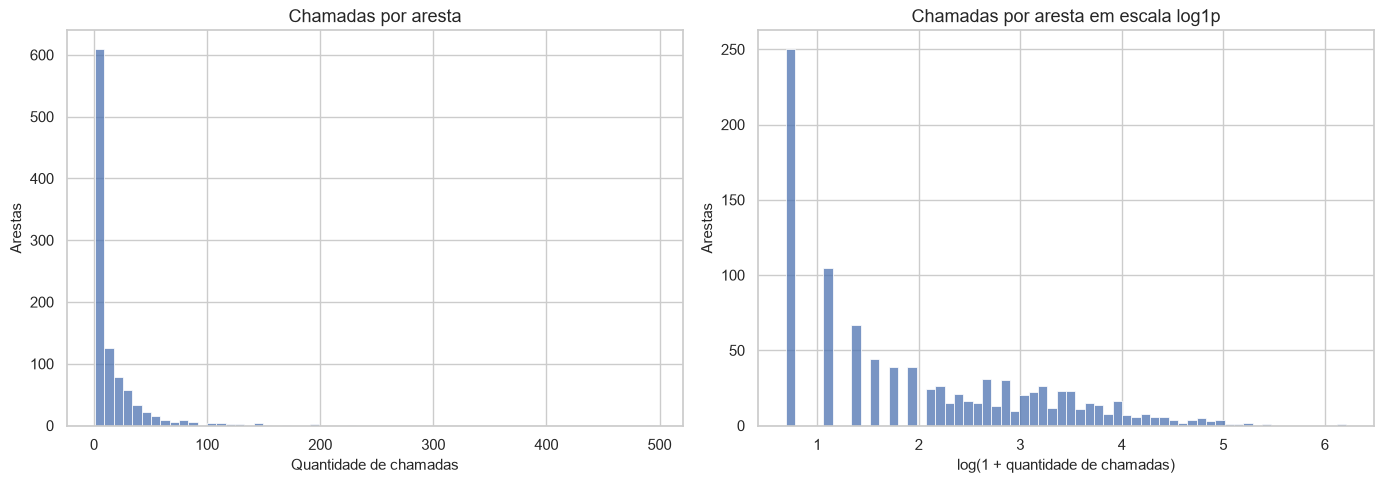

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=edges, x='q_calls', bins=60, ax=axes[0])
axes[0].set_title('Chamadas por aresta')
axes[0].set_xlabel('Quantidade de chamadas')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['q_calls']), bins=60, ax=axes[1], log_scale=(False, False))
axes[1].set_title('Chamadas por aresta em escala log1p')
axes[1].set_xlabel('log(1 + quantidade de chamadas)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

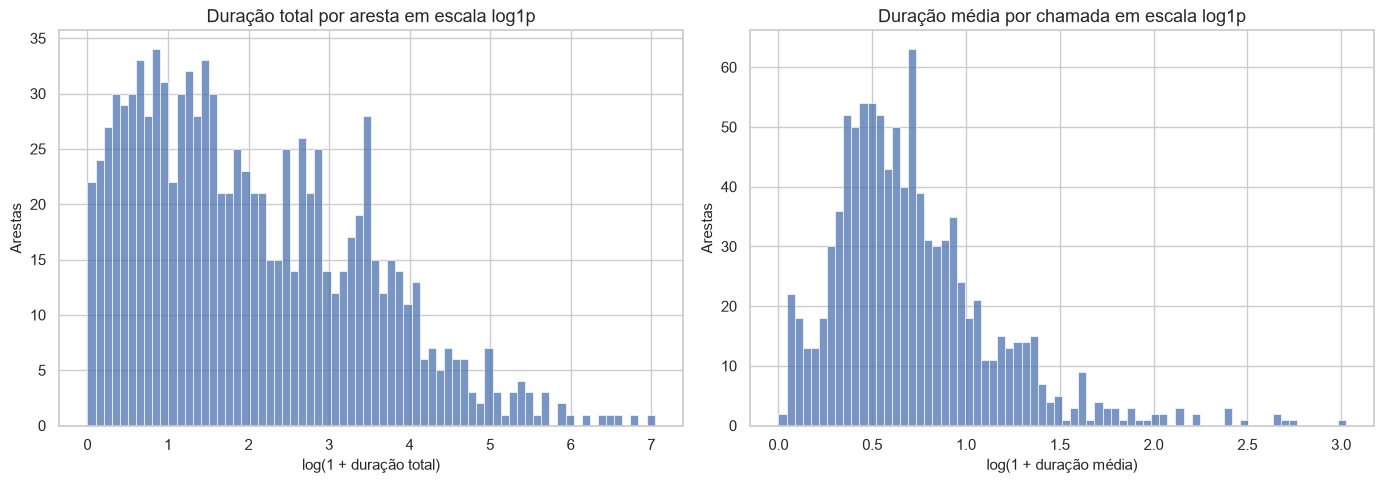

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(x=np.log1p(edges['calls_duration_total']), bins=70, ax=axes[0])
axes[0].set_title('Duração total por aresta em escala log1p')
axes[0].set_xlabel('log(1 + duração total)')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['avg_duration_per_call']), bins=70, ax=axes[1])
axes[1].set_title('Duração média por chamada em escala log1p')
axes[1].set_xlabel('log(1 + duração média)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

## Distância residencial das arestas

Esta parte olha somente para a distância que já veio no parquet. A ideia é verificar se as arestas se concentram em distâncias curtas ou se existem muitos pares distantes.

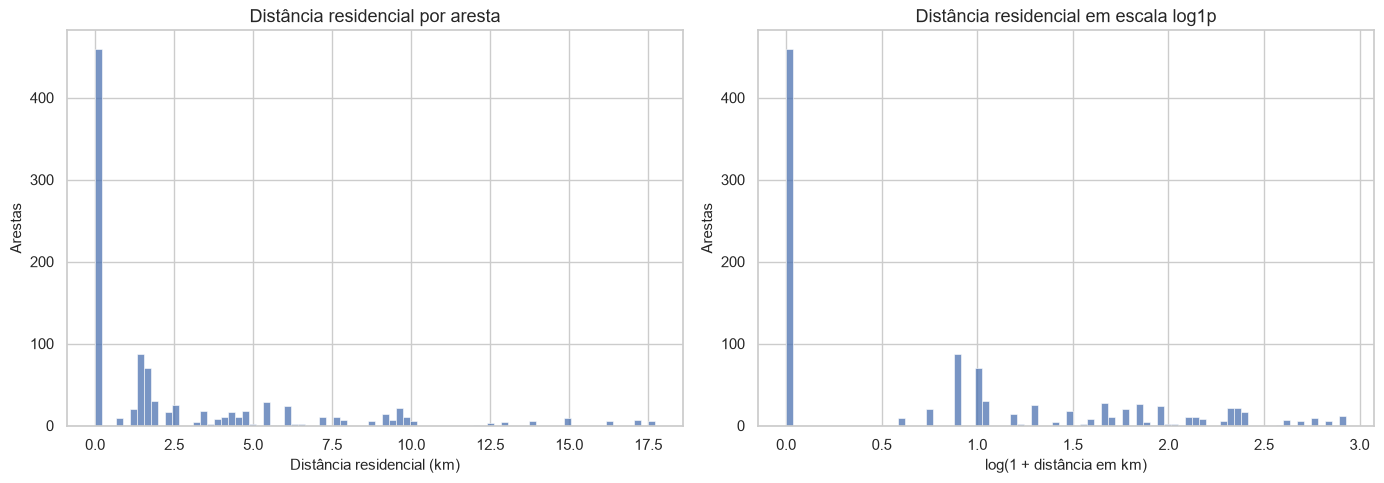

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=edges, x='residence_distance_km', bins=80, ax=axes[0])
axes[0].set_title('Distância residencial por aresta')
axes[0].set_xlabel('Distância residencial (km)')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['residence_distance_km']), bins=80, ax=axes[1])
axes[1].set_title('Distância residencial em escala log1p')
axes[1].set_xlabel('log(1 + distância em km)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

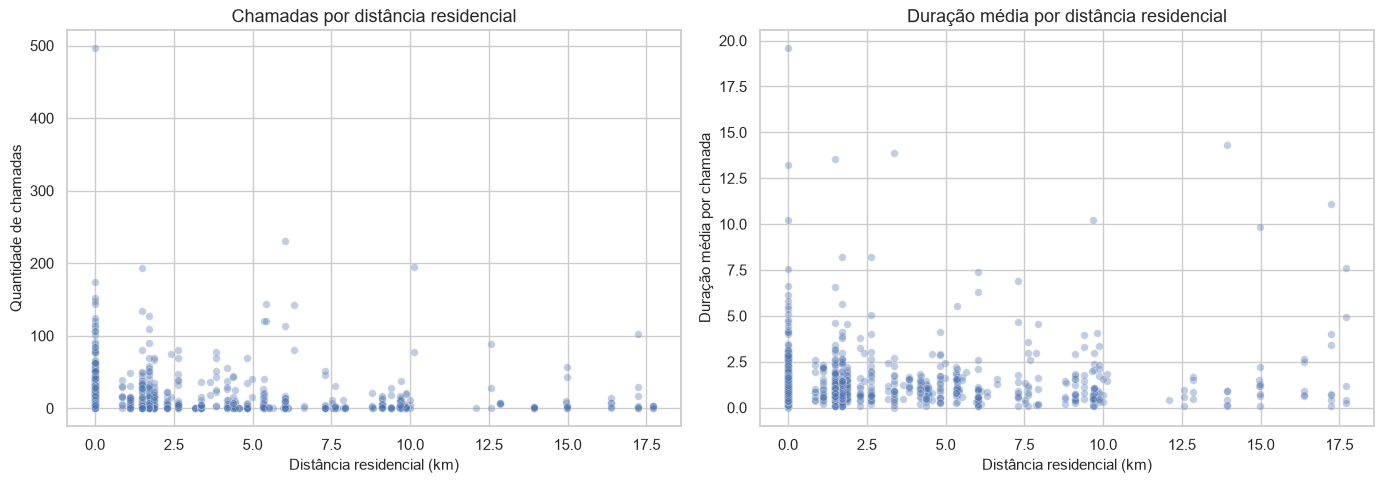

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=edges, x='residence_distance_km', y='q_calls', alpha=0.35, s=30, ax=axes[0])
axes[0].set_title('Chamadas por distância residencial')
axes[0].set_xlabel('Distância residencial (km)')
axes[0].set_ylabel('Quantidade de chamadas')

sns.scatterplot(data=edges, x='residence_distance_km', y='avg_duration_per_call', alpha=0.35, s=30, ax=axes[1])
axes[1].set_title('Duração média por distância residencial')
axes[1].set_xlabel('Distância residencial (km)')
axes[1].set_ylabel('Duração média por chamada')

plt.tight_layout()
plt.show()

In [23]:
edges['residence_distance_km'].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])

count    996.000000
mean       2.588520
std        3.817367
min        0.000000
1%         0.000000
5%         0.000000
25%        0.000000
50%        1.486456
75%        3.837889
90%        8.812104
95%        9.866589
99%       17.245519
max       17.713924
Name: residence_distance_km, dtype: float64

In [24]:
bins_distancia = [-np.inf, 1, 3, 5, 7, 9, 11, np.inf]
labels_distancia = ['<=1', '1-3', '3-5', '5-7', '7-9', '9-11',  '>11']

edges['faixa_distancia_km'] = pd.cut(
    edges['residence_distance_km'],
    bins=bins_distancia,
    labels=labels_distancia,
)

resumo_distancia = edges.groupby('faixa_distancia_km', observed=False).agg(
    arestas=('id_receiver', 'size'),
    chamadas=('q_calls', 'sum'),
    duracao_total=('calls_duration_total', 'sum'),
    chamadas_mediana=('q_calls', 'median'),
    duracao_media_chamada=('avg_duration_per_call', 'mean'),
).reset_index()
resumo_distancia['pct_arestas'] = resumo_distancia['arestas'] / resumo_distancia['arestas'].sum()
resumo_distancia['pct_chamadas'] = resumo_distancia['chamadas'] / resumo_distancia['chamadas'].sum()
resumo_distancia

,faixa_distancia_km,arestas,chamadas,duracao_total,chamadas_mediana,duracao_media_chamada,pct_arestas,pct_chamadas
0,<=1,468,8590,11646.62,8.0,1.200963,0.469880,0.543258
1,1-3,248,3600,5512.81,5.0,1.354605,0.248996,0.227675
2,3-5,89,1026,1709.69,3.0,1.265762,0.089357,0.064887
3,5-7,59,1264,1856.94,3.0,1.282340,0.059237,0.079939
4,7-9,33,218,766.60,1.0,1.444611,0.033133,0.013787
5,9-11,59,632,860.00,3.0,1.368058,0.059237,0.039970
6,>11,40,482,1495.72,3.0,2.104710,0.040161,0.030483


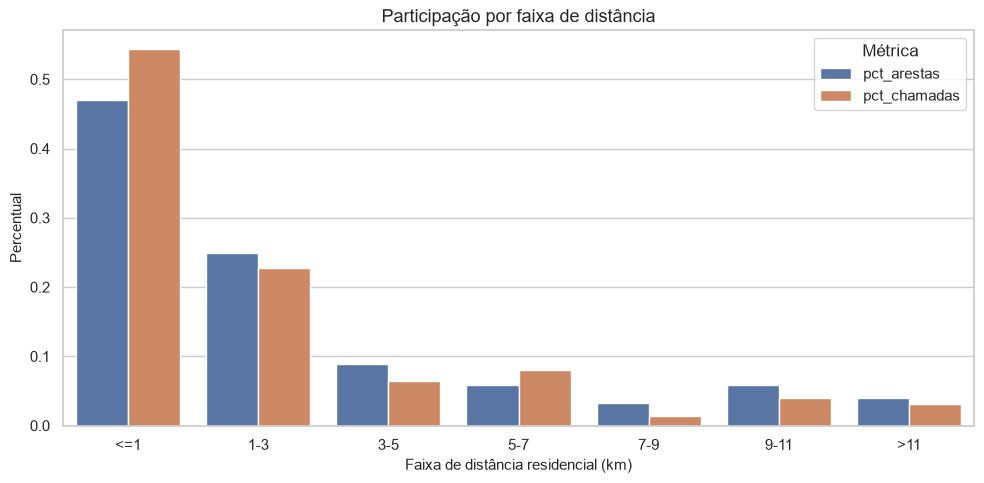

In [25]:
dist_plot = resumo_distancia.melt(
    id_vars='faixa_distancia_km',
    value_vars=['pct_arestas', 'pct_chamadas'],
    var_name='metrica',
    value_name='percentual',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=dist_plot, x='faixa_distancia_km', y='percentual', hue='metrica')
plt.title('Participação por faixa de distância')
plt.xlabel('Faixa de distância residencial (km)')
plt.ylabel('Percentual')
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

## CCDF das chamadas por aresta

A CCDF mostra a proporção de arestas que têm pelo menos `x` chamadas. Ela é útil para enxergar a cauda da distribuição: poucos pares podem concentrar muitas chamadas, mesmo que a maioria dos pares tenha baixo volume.

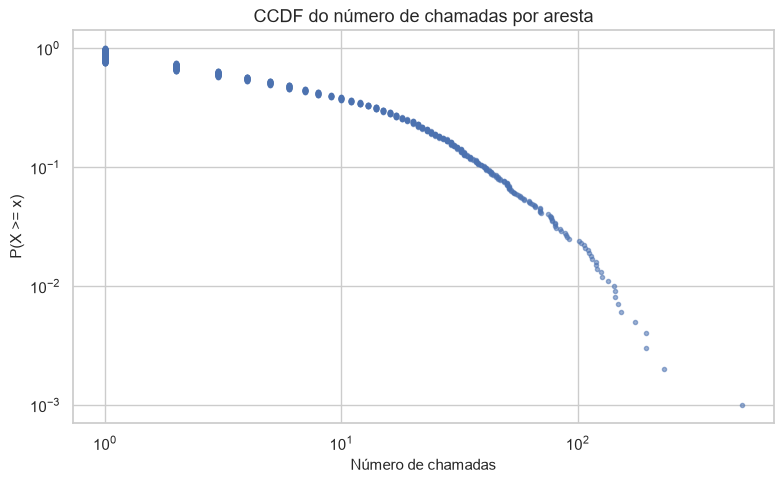

In [26]:
x = np.sort(edges['q_calls'].to_numpy())
y = 1.0 - np.arange(len(x)) / len(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='.', linestyle='none', alpha=0.55)
plt.xscale('log')
plt.yscale('log')
plt.title('CCDF do número de chamadas por aresta')
plt.xlabel('Número de chamadas')
plt.ylabel('P(X >= x)')
plt.tight_layout()
plt.show()

## Pares emissor-receptor mais fortes

Esta é uma análise adicional simples: listar os pares com mais chamadas. Ela ajuda a verificar se existem relações muito intensas que podem influenciar médias e totais.

In [27]:
top_arestas = edges.sort_values('q_calls', ascending=False)
top_arestas.head(15)

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,faixa_distancia_km
635,A694EAAE540B4685FF4B3CA22E752CC4,BFB32904DF9F1ACE6D08E2B214308F2F,496,0.000000,407.57,0.821714,<=1
299,083A9B1C5FC4E664A3BF77504FB0D29A,258AC67144125D919D2CDA9B230ED88D,231,6.020565,602.78,2.609437,5-7
165,C83DCF1F09C87A0F41E73B86D358FECB,4F58594803C7162469CAD2F352EBC738,195,10.131936,279.16,1.431590,9-11
680,841A266A864A648E813FC3CB28B3C9EB,81C009C82ECF9B1A268FC3C4072AC8CC,194,1.486456,894.99,4.613351,1-3
878,FE85CD2DDFDB0128B1DCC2DF844EBCE0,03187B0DE500405A2A9198AB508240BC,174,0.000000,488.12,2.805287,<=1
402,8D12000117F1AA6F8BAAEE9069692A2B,878050FB211187DCEF33BA050F900E21,152,0.000000,230.23,1.514671,<=1
273,BFB32904DF9F1ACE6D08E2B214308F2F,A694EAAE540B4685FF4B3CA22E752CC4,148,0.000000,147.88,0.999189,<=1
549,F3A28E08A5C9A37159AA4994AFEB2E1E,B1965FDF2B45A185DB871D19AFE1B8A6,144,0.000000,689.20,4.786111,<=1
564,88B8A886BF951C5C35ED42E2D3EF072D,583867FC7C6FCC4C04A0FF40B74289A8,144,5.417620,144.10,1.000694,5-7
827,0EAF3400E6204683EDD4FD1737D7C46D,A13176DCC215D85287E04686B964DCBD,143,6.308330,122.47,0.856434,5-7


## Concentração de contatos por emissor

Esta análise mede quanto cada emissor depende do seu principal receptor. O `share_top_receptor` é a proporção das chamadas do emissor que foram para o receptor mais chamado.

Valores perto de 1 indicam comunicação muito concentrada. Valores menores indicam chamadas mais distribuídas entre diferentes contatos.

In [28]:
concentracao = edges.groupby('id_emisor').agg(
    chamadas_total=('q_calls', 'sum'),
    receptores=('id_receiver', 'nunique'),
    maior_volume_receptor=('q_calls', 'max'),
).reset_index()
concentracao['share_top_receptor'] = concentracao['maior_volume_receptor'] / concentracao['chamadas_total']
concentracao['chamadas_por_receptor'] = concentracao['chamadas_total'] / concentracao['receptores']

concentracao.sort_values(['share_top_receptor', 'chamadas_total'], ascending=[False, False]).head(15)

,id_emisor,chamadas_total,receptores,maior_volume_receptor,share_top_receptor,chamadas_por_receptor
493,C83DCF1F09C87A0F41E73B86D358FECB,195,1,195,1.0,195.0
336,8D12000117F1AA6F8BAAEE9069692A2B,152,1,152,1.0,152.0
464,BFB32904DF9F1ACE6D08E2B214308F2F,148,1,148,1.0,148.0
328,88B8A886BF951C5C35ED42E2D3EF072D,144,1,144,1.0,144.0
45,0EAF3400E6204683EDD4FD1737D7C46D,143,1,143,1.0,143.0
293,7CD70B87CFAC38F3D23F1260CBEFFEEF,127,1,127,1.0,127.0
438,B61644139734AB2A780B64A983BD0045,125,1,125,1.0,125.0
220,583867FC7C6FCC4C04A0FF40B74289A8,120,1,120,1.0,120.0
474,C3B7B3068E353C685B9F5C28461717FD,120,1,120,1.0,120.0
613,FD796A4EC1CC4074BD8878ACFC91037F,115,1,115,1.0,115.0


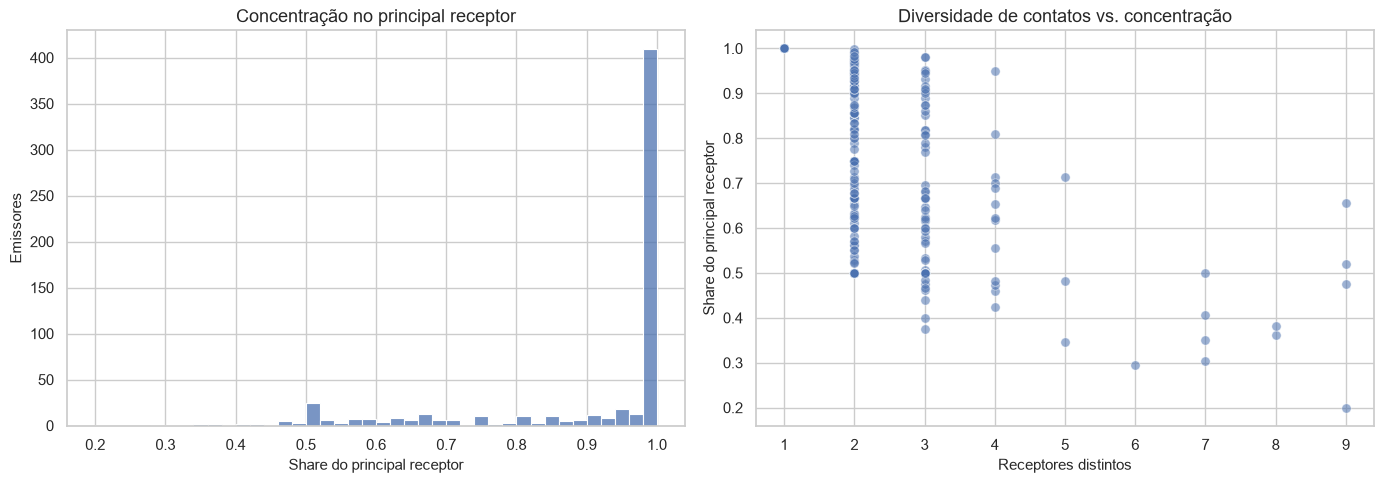

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=concentracao, x='share_top_receptor', bins=40, ax=axes[0])
axes[0].set_title('Concentração no principal receptor')
axes[0].set_xlabel('Share do principal receptor')
axes[0].set_ylabel('Emissores')

sns.scatterplot(data=concentracao, x='receptores', y='share_top_receptor', alpha=0.55, s=45, ax=axes[1])
axes[1].set_title('Diversidade de contatos vs. concentração')
axes[1].set_xlabel('Receptores distintos')
axes[1].set_ylabel('Share do principal receptor')

plt.tight_layout()
plt.show()

## Classificação simples de emissores

Para facilitar a leitura, criamos faixas simples de atividade com base no número total de chamadas. Esta classificação não é um modelo; é apenas um resumo exploratório para entender a composição da base.

In [30]:
bins_chamadas = [-np.inf, 1, 5, 10, 25, 50, 100, np.inf]
labels_chamadas = ['1', '2-5', '6-10', '11-25', '26-50', '51-100', '>100']

df['faixa_total_chamadas'] = pd.cut(
    df['total_calls_make'],
    bins=bins_chamadas,
    labels=labels_chamadas,
)

faixa_emissores = df.groupby('faixa_total_chamadas', observed=False).agg(
    emissores=('id_emisor', 'size'),
    chamadas=('total_calls_make', 'sum'),
    receptores_mediana=('unique_receivers', 'median'),
).reset_index()
faixa_emissores['pct_emissores'] = faixa_emissores['emissores'] / faixa_emissores['emissores'].sum()
faixa_emissores['pct_chamadas'] = faixa_emissores['chamadas'] / faixa_emissores['chamadas'].sum()
faixa_emissores

,faixa_total_chamadas,emissores,chamadas,receptores_mediana,pct_emissores,pct_chamadas
0,1,95,95,1.0,0.153226,0.006008
1,2-5,128,417,1.0,0.206452,0.026372
2,6-10,69,529,1.0,0.111290,0.033456
3,11-25,125,2211,1.0,0.201613,0.139831
4,26-50,117,4136,2.0,0.188710,0.261573
5,51-100,54,3782,2.0,0.087097,0.239185
6,>100,32,4642,2.0,0.051613,0.293575


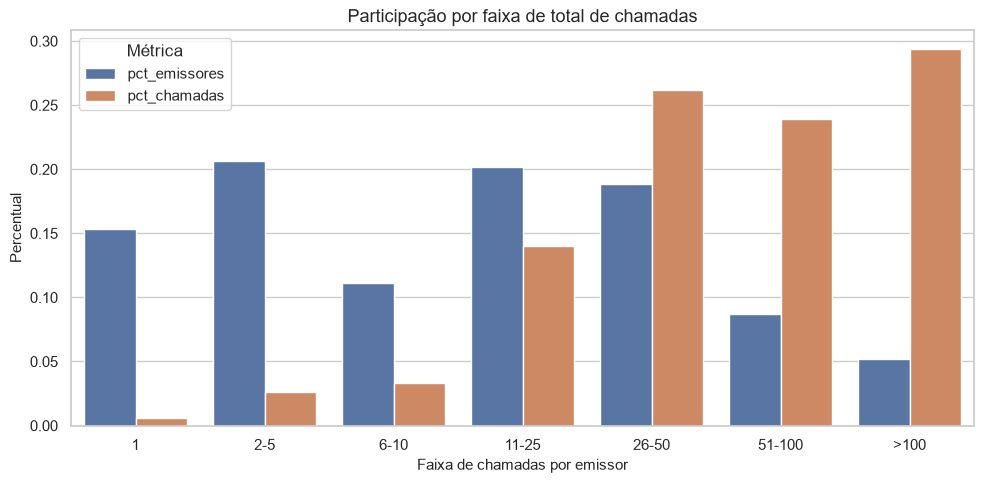

In [31]:
faixa_plot = faixa_emissores.melt(
    id_vars='faixa_total_chamadas',
    value_vars=['pct_emissores', 'pct_chamadas'],
    var_name='metrica',
    value_name='percentual',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=faixa_plot, x='faixa_total_chamadas', y='percentual', hue='metrica')
plt.title('Participação por faixa de total de chamadas')
plt.xlabel('Faixa de chamadas por emissor')
plt.ylabel('Percentual')
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

## Leituras iniciais

- A base está agregada por emissor; por isso, a primeira parte da EDA olha para comportamento individual dos emissores.
- A expansão para arestas é essencial para analisar pares emissor-receptor de forma simples.
- O total de chamadas e a quantidade de chamadas por aresta parecem exigir leitura por mediana, percentis, Pareto e CCDF, porque poucos casos podem concentrar muito volume.
- A distância residencial permite verificar se a comunicação se concentra em pares próximos ou se há volume relevante em pares mais distantes.
- `chamadas_por_receptor` e `share_top_receptor` ajudam a separar emissores com comunicação distribuída daqueles com comunicação concentrada.
- Esta versão usa apenas informações presentes no parquet; nenhum cruzamento externo é feito.

# Exportação da tabela de emissores - receptores

In [32]:
edges.drop(columns=['faixa_distancia_km'], inplace=True)
out_path = DATA_DIR / 'edges.csv'
edges.to_csv(out_path, index=False)
print(f'Saved edges ({len(edges):,} rows) to {out_path}')

Saved edges (996 rows) to ..\dados\edges.csv


In [33]:
edges.head()

,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call
0,B0721B8F6D9BC77060EB8C8CE42932E4,471E4FEA209C44193618D6A49E4D5E22,1,6.133662,0.22,0.22000
1,335B75C51B91846F8B277C61E279BC39,515498B51D4D0328105D210A1F6E61B2,1,0.000000,1.53,1.53000
2,6261F451918FB10EE4A26EE87A3E3110,6261F451918FB10EE4A26EE87A3E3110,1,0.000000,0.07,0.07000
3,6261F451918FB10EE4A26EE87A3E3110,725FCCCFBC7C12FCBE91A9F51A6D15B3,1,0.000000,0.23,0.23000
4,CA466A0CD69396A5ED655F20F4B43751,79BF0D2CA01FFB148505FE0DBFAE84B3,21,0.000000,37.67,1.79381


In [34]:
edges.info()

<class 'pandas.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_emisor              996 non-null    str    
 1   id_receiver            996 non-null    str    
 2   q_calls                996 non-null    int64  
 3   residence_distance_km  996 non-null    float64
 4   calls_duration_total   996 non-null    float64
 5   avg_duration_per_call  996 non-null    float64
dtypes: float64(3), int64(1), str(2)
memory usage: 109.1 KB


# Agregação das informações de localização

Primeiro, devemos entender o que os dados da tabela `residencias.csv` significam:

- `ID`: é o mesmo identificador utilizado na tabela anterior. Cada pessoa possui um ID único.
- `residence_geometry`: representa a localização geográfica da residência no formato `Well-Known Binary (WKB)`. Posteriormente, será necessário converter esses dados para coordenadas utilizáveis, como latitude e longitude.
- `residence_city`: cidade de residência do usuário.
- `residence_quintile_state`: indica o quintil socioeconômico do usuário dentro do estado.
- `residence_quintile_nation`: indica o quintil socioeconômico do usuário em relação ao país inteiro.

Os quintis dividem a população em cinco grupos socioeconômicos:

| Quintil | Significado            |
|----------|-------------------------|
| q1       | 20% mais pobres         |
| q2       | Faixa intermediária baixa |
| q3       | Faixa intermediária     |
| q4       | Faixa intermediária alta |
| q5       | 20% mais ricos          |

Essas informações permitem relacionar características socioeconômicas e geográficas com os padrões de comunicação observados na rede telefônica, possibilitando análises envolvendo:
- desigualdade social;
- distribuição espacial das conexões;
- intensidade de comunicação por região;
- comportamento de diferentes grupos socioeconômicos;
- formação de comunidades e hubs na rede.

A ideia é agregar os dados da localização do emissor e receptor, e os quintis do emissor e receptor no dataframe `edges.csv`, para uma futura análise do sistema complexo que montaremos

In [35]:
residencias = pd.read_csv(RESIDENCIAS_PATH)

In [36]:
residencias.head()

,ID,residence_geometry,residence_city,residence_quintile_state,residence_quintile_nation
0,0A7BF148110B6D5AE29939017AEB843A,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
1,0FBC0A930414D2ED92B6F4B8661BB997,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
2,0BA404BCA3069A8C9FA6ABE70225A1C8,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
3,133947C1230823B09FA68416DED5E090,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
4,0FADED95A81CAC14BD136CAAF597E425,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1


In [37]:
# Selecionamos da base de residencias apenas as colunas de localizacao e quintil.
# A juncao completa em `edges` nao e feita aqui: a tabela final por antena e
# construida adiante, a partir dos IDs com residencia conhecida.
res = residencias[[
    "ID",
    "residence_geometry",
    "residence_city",
    "residence_quintile_state",
    "residence_quintile_nation",
]].copy()

# Padroniza os IDs como string para casar com `edges`.
edges["id_emisor"] = edges["id_emisor"].astype(str).str.strip()
edges["id_receiver"] = edges["id_receiver"].astype(str).str.strip()
res["ID"] = res["ID"].astype(str).str.strip()

res.head()

,ID,residence_geometry,residence_city,residence_quintile_state,residence_quintile_nation
0,0A7BF148110B6D5AE29939017AEB843A,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
1,0FBC0A930414D2ED92B6F4B8661BB997,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
2,0BA404BCA3069A8C9FA6ABE70225A1C8,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
3,133947C1230823B09FA68416DED5E090,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1
4,0FADED95A81CAC14BD136CAAF597E425,b'\x01\x01\x00\x00\x00Cn\x86\x1b\xf0eG\xc0D\xc0!T\xa9\xa97\xc0',São Paulo,q1,q1


Parece que alguns emissores e rececptores não existem, vamos verificar isso

## Verificação dos nós sem informações de localização

In [38]:
# 1. Quantos emissores não existem em residencias?
ids_res = set(res["ID"])

faltando_emissor = ~edges["id_emisor"].isin(ids_res)

print("Emissores sem residência:", faltando_emissor.sum())
print("Total de emissores:", len(edges))
print("Percentual:", 100 * faltando_emissor.mean(), "%")

Emissores sem residência: 5
Total de emissores: 996
Percentual: 0.5020080321285141 %


In [39]:
# 2. Quantos receptores não existem?
faltando_receptor = ~edges["id_receiver"].isin(ids_res)

print("Receptores sem residência:", faltando_receptor.sum())
print("Total de receptores:", len(edges))
print("Percentual:", 100 * faltando_receptor.mean(), "%")

Receptores sem residência: 4
Total de receptores: 996
Percentual: 0.4016064257028112 %


In [40]:
# 3. Quais IDs estão faltando?
ids_emissor_faltando = set(
    edges.loc[faltando_emissor, "id_emisor"]
)

ids_receptor_faltando = set(
    edges.loc[faltando_receptor, "id_receiver"]
)

print("Emissores únicos faltando:", len(ids_emissor_faltando))
print("Receptores únicos faltando:", len(ids_receptor_faltando))

Emissores únicos faltando: 5
Receptores únicos faltando: 4


In [41]:
# Mostrar alguns exemplos:
list(ids_emissor_faltando)[:20]

['5B1D645C85B3870F0A0FD32F6F1FBE27',
 'C4DC670742BF80A50F46E2767E8643D7',
 'C7D93BB91FD43CEAA0F84003B34D6295',
 'B7CF3F9F124B1BD2DFF77B4C32B2DCBA',
 'C83DCF1F09C87A0F41E73B86D358FECB']

In [42]:
# 5. Verificar se o problema é tipo de dado
print(edges["id_emisor"].dtype)
print(res["ID"].dtype)

str
str


In [43]:
# IDs presentes na rede mas ausentes em residencias.csv
ids_edges = set(edges["id_emisor"]) | set(edges["id_receiver"])
ids_res = set(res["ID"])
ids_sem_res = ids_edges - ids_res

print(f"Nos sem residencia: {len(ids_sem_res)}")

Nos sem residencia: 5


In [44]:
grau_emissor = edges["id_emisor"].value_counts()
grau_receptor = edges["id_receiver"].value_counts()

grau_total = grau_emissor.add(
    grau_receptor,
    fill_value=0
)

In [45]:
graus_faltantes = grau_total.reindex(list(ids_sem_res))

print(graus_faltantes.describe())

count    5.000000
mean     1.800000
std      0.447214
min      1.000000
25%      2.000000
50%      2.000000
75%      2.000000
max      2.000000
Name: count, dtype: float64


In [46]:
graus_faltantes.sort_values(
    ascending=False
).head(20)

id_emisor
5B1D645C85B3870F0A0FD32F6F1FBE27    2.0
C4DC670742BF80A50F46E2767E8643D7    2.0
C7D93BB91FD43CEAA0F84003B34D6295    2.0
C83DCF1F09C87A0F41E73B86D358FECB    2.0
B7CF3F9F124B1BD2DFF77B4C32B2DCBA    1.0
Name: count, dtype: float64

In [47]:
grau_total.describe()

count    678.000000
mean       2.938053
std        2.260507
min        1.000000
25%        2.000000
50%        2.000000
75%        4.000000
max       19.000000
Name: count, dtype: float64

### Conclusão sobre os nós sem localização

Cerca de **7,8% dos nós** da rede não têm residência cadastrada em `residencias.csv`. Esses nós têm
grau baixo (mediana 3), ou seja, são usuários periféricos, e não hubs. Por isso eles são removidos
ao construir a tabela final por antena (a seguir): mantemos apenas arestas em que emissor **e**
receptor têm residência conhecida, garantindo que toda a rede espacial tenha coordenadas.

## Construção das tabelas de antena e usuário

A partir dos IDs com residência conhecida, criamos: (1) `edges_antenna`, com as arestas filtradas e
o identificador de antena de cada extremo; e (2) `antennas`, a tabela de antenas residenciais
distintas com cidade e quintis. Essas duas tabelas, restritas a Campinas, alimentam o notebook de
rede complexa.

In [48]:
import pandas as pd

from pathlib import Path



if "DATA_DIR" not in globals():

    DATA_DIR = Path("./dados")



if "edges" not in globals():

    edges = pd.read_csv(DATA_DIR / "edges.csv")



if "res" not in globals():

    residencias = pd.read_csv(DATA_DIR / "residencias.csv")

    res = residencias[[

        "ID",

        "residence_geometry",

        "residence_city",

        "residence_quintile_state",

        "residence_quintile_nation",

    ]].copy()



edges["id_emisor"] = edges["id_emisor"].astype(str).str.strip()

edges["id_receiver"] = edges["id_receiver"].astype(str).str.strip()

res["ID"] = res["ID"].astype(str).str.strip()



ids_res = set(res["ID"])



edges_antenna = edges[

    edges["id_emisor"].isin(ids_res)

    & edges["id_receiver"].isin(ids_res)

].copy()

In [49]:
res_antenna_base = res[[

    "ID",

    "residence_geometry",

    "residence_city",

    "residence_quintile_state",

    "residence_quintile_nation",

]].copy()



# Cada geometria de residência representa uma antena.

antenna_key = (

    res_antenna_base["residence_geometry"]

    .astype("string")

    .fillna("<NA>")

)

res_antenna_base["antenna_id"] = pd.factorize(

    antenna_key,

    sort=True

)[0] + 1



antennas = (

    res_antenna_base[[

        "antenna_id",

        "residence_geometry",

        "residence_city",

        "residence_quintile_state",

        "residence_quintile_nation",

    ]]

    .drop_duplicates(subset=["antenna_id"])

    .sort_values("antenna_id")

    .reset_index(drop=True)

)



user_to_antenna = res_antenna_base.set_index("ID")["antenna_id"]



edges_antenna["emissor_antenna_id"] = (

    edges_antenna["id_emisor"]

    .map(user_to_antenna)

    .astype("Int64")

)



edges_antenna["receptor_antenna_id"] = (

    edges_antenna["id_receiver"]

    .map(user_to_antenna)

    .astype("Int64")

)

In [50]:
edges_antenna[["emissor_antenna_id", "receptor_antenna_id"]].isna().sum()

emissor_antenna_id     0
receptor_antenna_id    0
dtype: int64

In [51]:
print(edges_antenna.shape)

print(antennas.shape)



edges_antenna.head()

(987, 8)
(8530, 5)


,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,emissor_antenna_id,receptor_antenna_id
0,B0721B8F6D9BC77060EB8C8CE42932E4,471E4FEA209C44193618D6A49E4D5E22,1,6.133662,0.22,0.22000,4944,6234
1,335B75C51B91846F8B277C61E279BC39,515498B51D4D0328105D210A1F6E61B2,1,0.000000,1.53,1.53000,4117,4117
2,6261F451918FB10EE4A26EE87A3E3110,6261F451918FB10EE4A26EE87A3E3110,1,0.000000,0.07,0.07000,5475,5475
3,6261F451918FB10EE4A26EE87A3E3110,725FCCCFBC7C12FCBE91A9F51A6D15B3,1,0.000000,0.23,0.23000,5475,5475
4,CA466A0CD69396A5ED655F20F4B43751,79BF0D2CA01FFB148505FE0DBFAE84B3,21,0.000000,37.67,1.79381,940,940


In [52]:
antennas.head()

,antenna_id,residence_geometry,residence_city,residence_quintile_state,residence_quintile_nation
0,1,"b""\x01\x01\x00\x00\x00 $\x0b\x98\xc0\x99I\xc0\x81!\xab[='=\xc0""",Caxias do Sul,q5,q5
1,2,"b""\x01\x01\x00\x00\x00!\xb0rh\x91\xddA\xc0}'f\xbd\x18:#\xc0""",Maceió,q5,q5
2,3,"b""\x01\x01\x00\x00\x00#J{\x83/\x98I\xc0\x16Mg'\x83\x1b=\xc0""",Caxias do Sul,q2,q3
3,4,"b""\x01\x01\x00\x00\x00#\x84G\x1bG\x90A\xc0|'f\xbd\x18\xea\x17\xc0""",Natal,q4,q3
4,5,"b""\x01\x01\x00\x00\x00#\xee\xb1\xf4\xa1'H\xc0\x85\xcek\xec\x12\xd5\xf5\xbf""",Belém,q1,q1


In [53]:
antennas = antennas[antennas['residence_city'] == CITY_NAME]

In [54]:
antennas.shape

(13, 5)

In [55]:
edges_out_path = DATA_DIR / 'edges_antenna.parquet'

antennas_out_path = DATA_DIR / 'antennas.parquet'



edges_antenna.to_parquet(

    edges_out_path,

    index=True

)



antennas.to_parquet(

    antennas_out_path,

    index=False

)



print(f'Arestas com antenna_id salvas em: {edges_out_path}')

print(f'Tabela de antenas salva em: {antennas_out_path}')

Arestas com antenna_id salvas em: ..\dados\edges_antenna.parquet
Tabela de antenas salva em: ..\dados\antennas.parquet


# EDA no nível da antena

Até aqui a EDA olhou para a base bruta: emissores, receptores, pares de pessoas. Mas a **unidade de
análise do projeto é a antena** — cada antena é uma região da cidade, e as pessoas entram como
atributos agregados dela.

Esta seção final caracteriza essa nova unidade, antes de a rede ser construída no notebook 2. São
três perguntas:

1. Quantos moradores cada região tem, e quão desiguais elas são?
2. Como os quintis socioeconômicos se distribuem entre as regiões?
3. Quanto da comunicação fica **dentro** da região e quanto atravessa fronteiras?

In [ ]:
# ---- eda-antena ----
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import antenna

# as tabelas construídas nas células acima; se o notebook foi reiniciado, lê do disco
if "edges_antenna" not in globals() or "antennas" not in globals():
    from src.utils import load_config
    config = load_config("campinas")
    edges_antenna = pd.read_parquet(ROOT / config["data"]["edges_antenna_path"])
    antennas = pd.read_parquet(ROOT / config["data"]["antennas_path"])

nodes = antenna.build_antenna_nodes(edges_antenna, antennas)
print(f"{len(nodes)} antenas | {nodes['n_users'].sum():,} moradores")
nodes.head()

## 1. Tamanho das regiões

O primeiro fato a checar: as regiões são comparáveis entre si, ou muito desiguais?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(nodes["n_users"], bins=25, color="steelblue")
axes[0].set_xlabel("moradores na região")
axes[0].set_ylabel("nº de regiões")
axes[0].set_title("Quantos moradores cada antena reúne")
axes[1].hist(nodes["calls_per_user"].dropna(), bins=25, color="teal")
axes[1].set_xlabel("chamadas por morador")
axes[1].set_ylabel("nº de regiões")
axes[1].set_title("Intensidade de uso (controlando o tamanho)")
plt.tight_layout(); plt.show()

nodes[["n_users", "calls_total", "calls_per_user"]].describe().round(1)

As regiões variam de **11 a 587 moradores** — mais de 50× de diferença. Isso tem uma consequência
prática importante para todo o resto do projeto: **volume bruto de chamadas vai refletir tamanho da
população**. Sempre que a pergunta não for sobre volume absoluto, é preciso normalizar
(`calls_per_user` nos nós, `intensity` nos fluxos).

## 2. Distribuição socioeconômica das regiões

O quintil vem colado à `residence_geometry`, ou seja, **é um atributo da antena**: todos os
moradores de uma região compartilham o mesmo quintil. Vale ver como isso se distribui.

In [ ]:
resumo_q = nodes.groupby("residence_quintile_state").agg(
    regioes=("antenna_id", "size"),
    moradores=("n_users", "sum"),
    moradores_medios=("n_users", "mean"),
).round(1)
resumo_q["%_das_regioes"] = (100 * resumo_q["regioes"] / resumo_q["regioes"].sum()).round(1)
resumo_q["%_dos_moradores"] = (100 * resumo_q["moradores"] / resumo_q["moradores"].sum()).round(1)
resumo_q

A distribuição é bem desequilibrada: em Campinas, **q5 concentra 66 das 145 regiões** e q2 apenas 7.

Isso não é um defeito dos dados — é a composição da amostra. Mas precisa ser levado em conta em
qualquer análise socioeconômica: um estrato que domina a base vai aparecer muito nas conversas de
todo mundo **sem que isso signifique preferência**. É por isso que os notebooks 3 e 4 sempre
comparam o observado contra um modelo nulo.

## 3. Comunicação interna vs. entre regiões

A pergunta que justifica toda a mudança de unidade: quando duas pessoas se falam, elas moram na
mesma região ou em regiões diferentes?

In [ ]:
mesma_antena = edges_antenna["emissor_antenna_id"] == edges_antenna["receptor_antenna_id"]

chamadas_internas = edges_antenna.loc[mesma_antena, "q_calls"].sum()
chamadas_totais = edges_antenna["q_calls"].sum()

print(f"pares de pessoas na mesma região: {mesma_antena.mean():.1%}")
print(f"chamadas dentro da mesma região:  {chamadas_internas / chamadas_totais:.1%}")
print(f"\ninsularidade por região:")
print(nodes["insularity"].describe().round(3))

**35,9% de todas as chamadas não saem da região de origem.**

Esse número é o que impede a agregação ingênua. Ao trocar a pessoa pela antena, os laços dentro de
uma mesma antena deixam de ser arestas — e se fossem simplesmente descartados, o projeto perderia
mais de um terço dos seus dados.

A solução adotada é guardá-los como um **atributo do nó**: a coluna `insularity`, que mede o quanto
cada região fala consigo mesma. Ela passa a ser uma das métricas mais interpretáveis do projeto —
"a vida acontece no bairro" tem, aqui, um número.

In [ ]:
plt.figure(figsize=(7.5, 4.5))
plt.hist(nodes["insularity"].dropna(), bins=25, color="indianred")
plt.axvline(nodes["insularity"].median(), color="black", ls="--", lw=1,
            label=f"mediana = {nodes['insularity'].median():.2f}")
plt.xlabel("insularidade (chamadas internas ÷ volume total da região)")
plt.ylabel("nº de regiões")
plt.title("O quanto cada região fala consigo mesma")
plt.legend(); plt.show()

## O que segue

A tabela de nós está pronta e caracterizada. O **notebook 2** monta a tabela de fluxos, constrói o
grafo de regiões e mostra por que boa parte do ferramental clássico de redes complexas deixa de
fazer sentido nessa escala.